In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Unnormalized target density
def target_density(x):
    return np.exp(-(x - 2)**2 / 2) + np.exp(-(x - 8)**2 / 2)

# Metropolis sampler
def metropolis(num_samples=50000, sigma=2.0, x0=0):
    samples = np.zeros(num_samples)
    x_current = x0
    accepted = 0

    for t in range(num_samples):
        # Proposal
        x_proposal = np.random.normal(x_current, sigma)

        # Acceptance ratio
        alpha = target_density(x_proposal) / target_density(x_current)
        acceptance_prob = min(1, alpha)

        # Accept/reject
        if np.random.rand() < acceptance_prob:
            x_current = x_proposal
            accepted += 1

        samples[t] = x_current

    acceptance_rate = accepted / num_samples

    return samples, acceptance_rate

In [7]:
samples, acc_rate = metropolis(num_samples=50000, sigma=2.0)

# Burn-in removal
burn_in = 5000
samples_burned = samples[burn_in:]

print("Acceptance rate:", acc_rate)

Acceptance rate: 0.53274


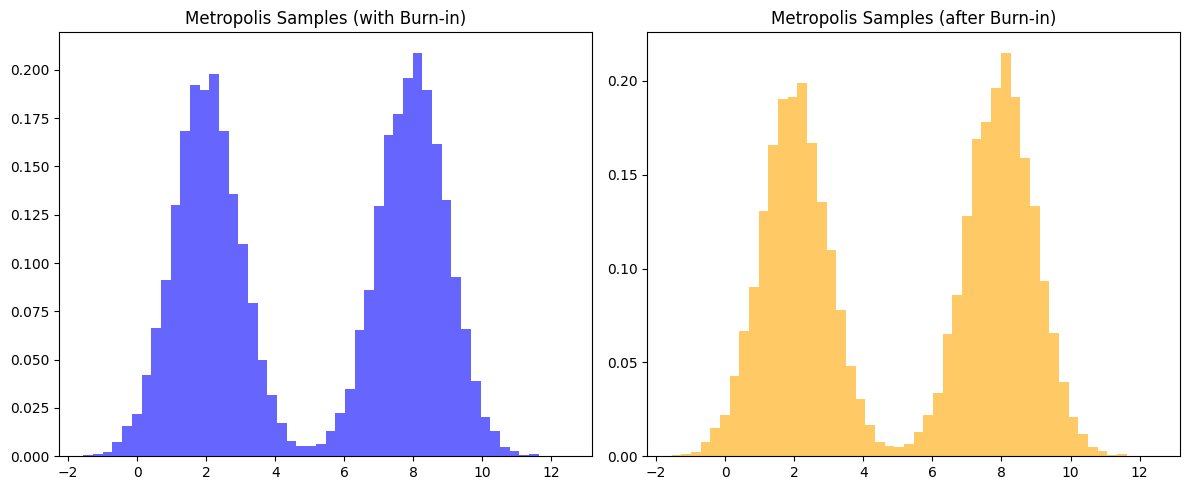

In [9]:
# Visualization with and without burn-in
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(samples, bins=50, density=True, alpha=0.6, color='blue')
plt.title('Metropolis Samples (with Burn-in)')
plt.subplot(1, 2, 2)
plt.hist(samples_burned, bins=50, density=True, alpha=0.6, color='orange')
plt.title('Metropolis Samples (after Burn-in)')
plt.tight_layout()
plt.show()



In [5]:
#  Efect of sigma
sigmas = [0.1, 2.0, 15.0]
results = {}

for s in sigmas:
    _, acc = metropolis(num_samples=50000, sigma=s)
    results[s] = acc

print(results)

{0.1: 0.97214, 2.0: 0.52854, 15.0: 0.16252}
